# Deep Agents - Backend


## 1. Backend란?

Deep Agents는 파일 시스템 인터페이스를 에이전트에게 제공합니다. 에이전트는 `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep` 같은 도구를 사용할 수 있습니다.

이러한 도구들은 **Backend**를 통해 작동하며, Backend는 플러그인 방식으로 교체 가능합니다.

### Backend의 역할
- 에이전트가 파일을 읽고 쓸 수 있는 공간 제공
- 임시 저장소(ephemeral) 또는 영구 저장소(persistent) 선택 가능
- 다양한 저장 방식 지원: 메모리, 로컬 디스크, 데이터베이스, 클라우드 스토리지 등


## 2. Built-in Backends 비교

| Backend | 저장 위치 | 지속성 | 사용 사례 |
|---------|----------|--------|-----------|
| **StateBackend** (기본) | LangGraph State | 단일 스레드 내에서만 유지 | 임시 작업, 스크래치 패드 |
| **FilesystemBackend** | 로컬 디스크 | 영구 저장 | 로컬 프로젝트, CI 샌드박스 |
| **StoreBackend** | LangGraph Store | 여러 스레드 간 공유 | 장기 메모리, 크로스 스레드 데이터 |


## 3. Setup

### 환경 변수 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)


In [1]:
from dotenv import load_dotenv

load_dotenv()


True

### LLM 정의 

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


### (옵션) PostgreSQL 구축 

> 만약 PostgreSQL이 설치되지 않았다면, docker-compose.yml을 이용해서 설치 

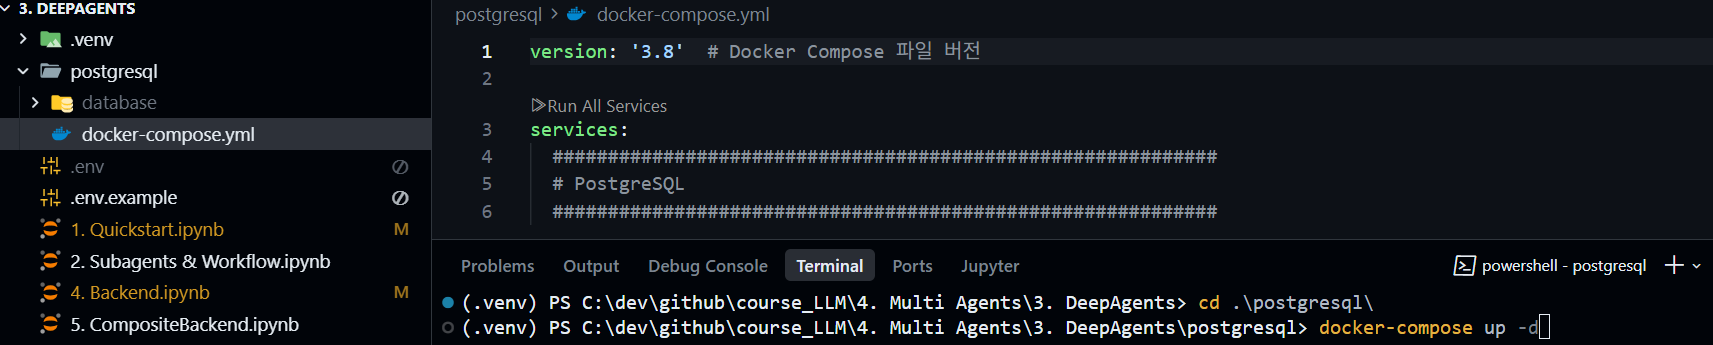

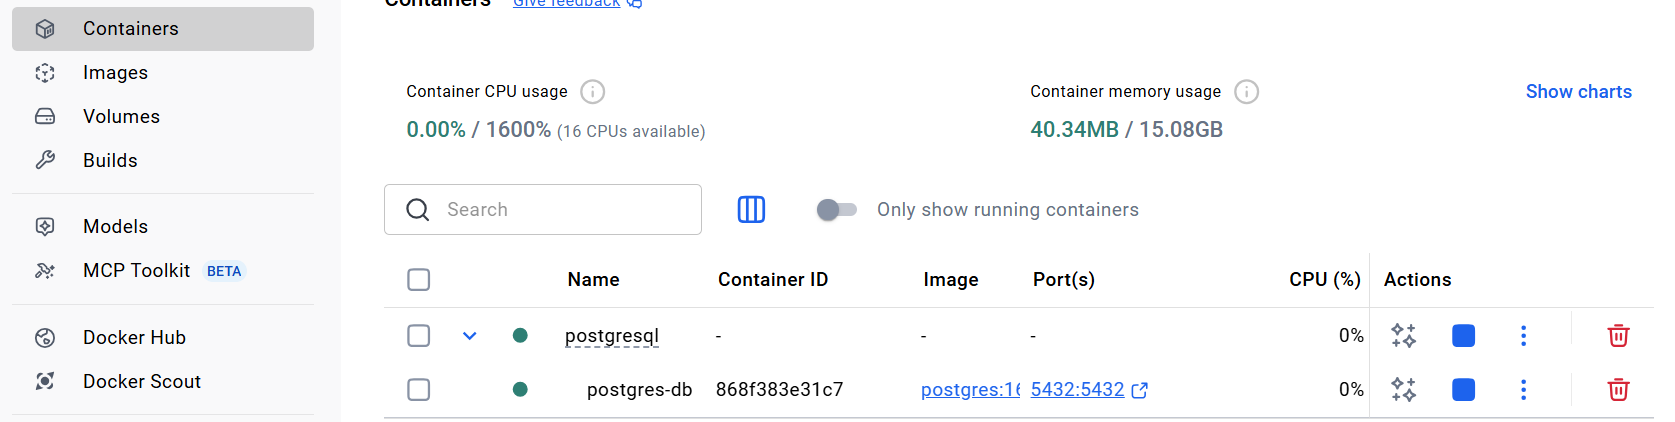

### Checkpointer 정의 

멀티 에이전트 그래프가 실행되다가 중단되거나, 다음 턴에서 이어서 실행할 수 있도록 모든 중간 상태(메모리, 메시지, 노드 진행 상황)를 자동 저장하는 저장 장치

In [3]:
class Singleton(type):
	_instances = {}

	def __call__(cls, *args, **kwargs):
		if cls not in cls._instances:
			cls._instances[cls] = super(Singleton, cls)\
				.__call__(*args, **kwargs)
		return cls._instances[cls]


In [4]:
import psycopg

class PostgreDB(metaclass=Singleton):
    def __init__(self, DB_CONFIG:dict):
        # PostgreSQL 연결 설정
        DB_URI = f"postgresql://{DB_CONFIG['user']}:{DB_CONFIG['password']}@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['database']}"

        self.conn = psycopg.connect(DB_URI, autocommit=True)

    def get_conn(self):
        return self.conn

In [5]:
# PostgreSQL 연결 설정
DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "langchain_db",
    "user": "admin",
    "password": "admin123"  # 실제 운영에서는 환경변수로 관리!
}

In [6]:
# 싱글톤 패턴 동작 확인
print("\n=== 싱글톤 패턴 동작 확인 ===")
conn1 = PostgreDB(DB_CONFIG).get_conn()
conn2 = PostgreDB(DB_CONFIG).get_conn()

print(f"\n첫 번째 연결: {conn1}")
print(f"두 번째 연결: {conn2}")
print(f"같은 연결인가? {conn1 is conn2}")  # True여야 함
print("\n✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.")


=== 싱글톤 패턴 동작 확인 ===

첫 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=langchain_db) at 0x1624f0e63c0>
두 번째 연결: <psycopg.Connection [IDLE] (host=localhost user=admin database=langchain_db) at 0x1624f0e63c0>
같은 연결인가? True

✓ 싱글톤 패턴 적용 완료! 동일한 연결을 재사용합니다.


In [7]:
from langgraph.checkpoint.postgres import PostgresSaver


checkpointer = PostgresSaver(PostgreDB(DB_CONFIG).get_conn())
checkpointer.setup()  # 필요한 테이블 자동 생성
print("Checkpointer가 생성되었습니다!")

Checkpointer가 생성되었습니다!


> PostgresSaver가 생성하는 주요 테이블들

| 테이블명                      | 역할                   |
| ------------------------- | -------------------- |
| **checkpoints**           | 메인 체크포인트 저장 테이블      |
| **checkpoint_blobs**      | 큰 상태(blob) 데이터 저장    |
| **checkpoint_writes**     | 쓰기 중 충돌 방지 & lock 관리 |
| **checkpoint_migrations** | 스키마 버전/마이그레이션 기록     |


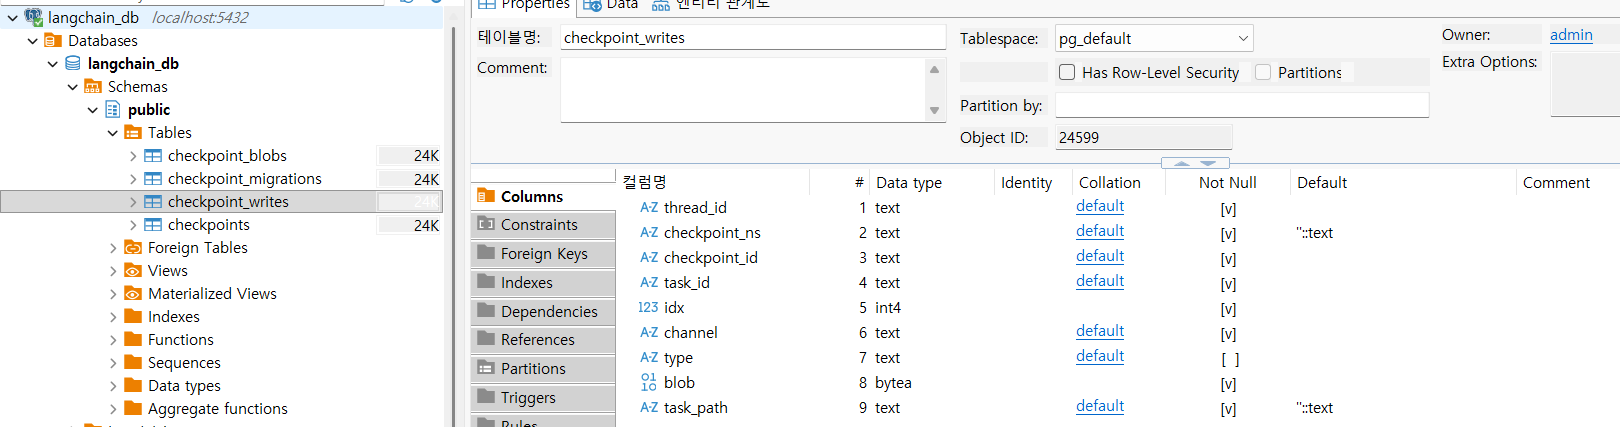

## 4. StateBackend (기본 - 임시 저장소)

`StateBackend`는 Deep Agents의 기본 백엔드입니다.


### 특징
- LangGraph의 State에 파일을 저장
- 체크포인트를 통해 동일 스레드 내에서는 여러 턴에 걸쳐 유지됨
- 스레드가 종료되면 데이터도 사라짐
- 에이전트의 스크래치 패드로 사용하기 적합

In [33]:
from deepagents import create_deep_agent

# 기본적으로 StateBackend가 사용됩니다
agent = create_deep_agent(
    model=llm,
    checkpointer=checkpointer,
    system_prompt="""
    당신은 사용자에게 도움을 주는 어시스턴트입니다.
    """
)

# 또는 명시적으로 지정:
# from deepagents.backends import StateBackend
# agent = create_deep_agent(model=llm, backend=lambda rt: StateBackend(rt))


### StateBackend 테스트

에이전트에게 파일을 생성하고 읽도록 요청해봅시다.


1. **자연어 인터페이스**: Agent에게 자연어로 파일 작업을 요청할 수 있습니다
2. **가상 파일 시스템**: Deep Agent가 관리하는 내부 저장소를 사용합니다
3. **Thread 격리**: 각 thread_id는 독립적인 파일 시스템 공간을 가집니다
4. **주요 작업**:
   - 파일 생성 및 쓰기
   - 파일 읽기
   - 파일 목록 조회
   - 파일 수정 및 삭제
   - 디렉토리 생성 및 관리

In [34]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "state-backend-test"}}

response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="/workspace/notes.txt 파일을 만들고 'StateBackend 테스트입니다'라고 작성해줘.")
        ]
    },
    config=config
)

print(response["messages"][-1].content)


파일이 이미 존재하여 덮어쓰기가 거부되었습니다. 내용을 업데이트해 드렸습니다.

다음은 현재 파일 내용입니다:
StateBackend 테스트입니다

확인하시고 다른 수정이나 파일 생성을 원하시면 말씀해 주세요.


#### Checkpointer에 저장된 대화 내용 데이터 확인 
- 같은 `thread_id`를 사용하면 이전에 생성한 파일에 접근할 수 있습니다

In [35]:
# 같은 스레드에서 파일 읽기
response = agent.invoke(
    {
        "messages": [
            HumanMessage(content="이전에 생성했던 파일 내용을 읽어줘.")
        ]
    },
    config=config
)

print(response["messages"][-1].content)

다음과 같이 읽혔습니다:
StateBackend 테스트입니다

파일은 한 줄로 구성되어 있습니다. 다른 파일도 읽어드릴까요?


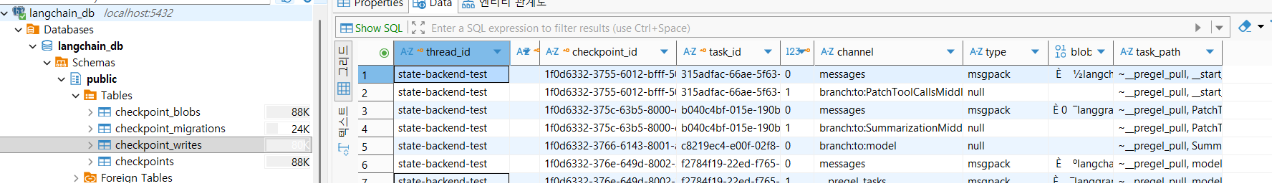

#### [Langsmith](https://smith.langchain.com/)

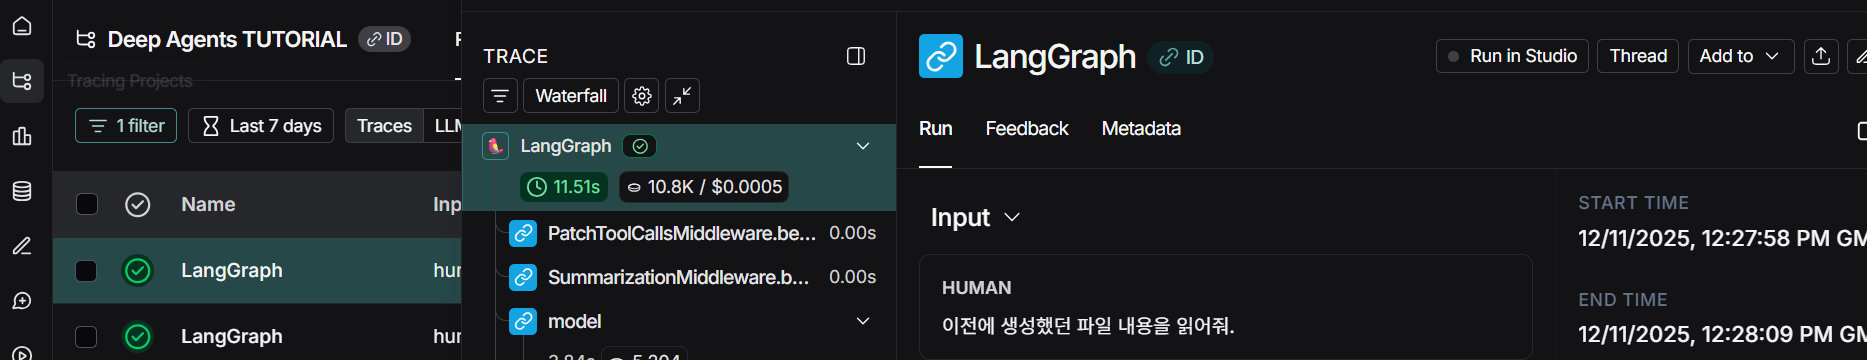

## 5. FilesystemBackend (로컬 디스크 저장)

`FilesystemBackend`는 실제 로컬 디스크에 파일을 읽고 쓸 수 있게 해줍니다.


In [18]:
import os
from pathlib import Path

# 임시 디렉토리 생성 (절대 경로로 변환)
temp_dir = Path("./temp").resolve()

# exist_ok=True → 폴더가 이미 있어도 에러 안냄
os.makedirs(temp_dir, exist_ok=True)

print("폴더 생성 완료:", temp_dir)


폴더 생성 완료: C:\dev\github\course_LLM\4. Multi Agents\3. DeepAgents\temp


### 특징
- 설정한 `root_dir` 아래의 실제 파일 시스템에 접근
- 영구 저장 - 에이전트 재시작 후에도 유지
- `virtual_mode=True` 옵션으로 경로를 샌드박스화하고 정규화 가능
- 보안: 안전한 경로 해석, symlink traversal 방지

In [19]:
from deepagents import create_deep_agent
from deepagents.backends import FilesystemBackend

# FilesystemBackend 사용
agent_fs = create_deep_agent(
    model=llm,
    system_prompt="""
    당신은 사용자에게 도움을 주는 어시스턴트입니다.
    """,
    backend=FilesystemBackend(root_dir=temp_dir, virtual_mode=True)
)


### FilesystemBackend 테스트


In [20]:
from langchain.messages import HumanMessage

config_fs = {"configurable": {"thread_id": "filesystem-backend-test"}}

response = agent_fs.invoke(
    {
        "messages": [
            HumanMessage(content="""
다음 작업을 수행해주세요:
1. /project/data.json 파일을 만들고 {"name": "test", "value": 100} 내용을 작성
2. /project/readme.md 파일을 만들고 '프로젝트 설명' 내용을 작성
3. /project 디렉토리의 파일 목록을 보여주세요""")
        ]
    },
    config=config_fs
)

print(response["messages"][-1].content)


작업을 완료했습니다.

- /project/data.json 생성 및 내용 저장
  - {"name": "test", "value": 100}
- /project/readme.md 생성 및 내용 저장
  - 프로젝트 설명
- /project 디렉토리의 파일 목록
  - /project/data.json
  - /project/readme.md

참고: 파일 목록 조회 시 경로 표기가 '/\\project\\data.json'와 같이 보일 수 있지만 실제 경로는 /project/data.json 입니다. 필요하시면 다시 확인해 드리겠습니다.

다음에 더 도와드릴 일 있을까요?


#### [Langsmith](https://smith.langchain.com/)

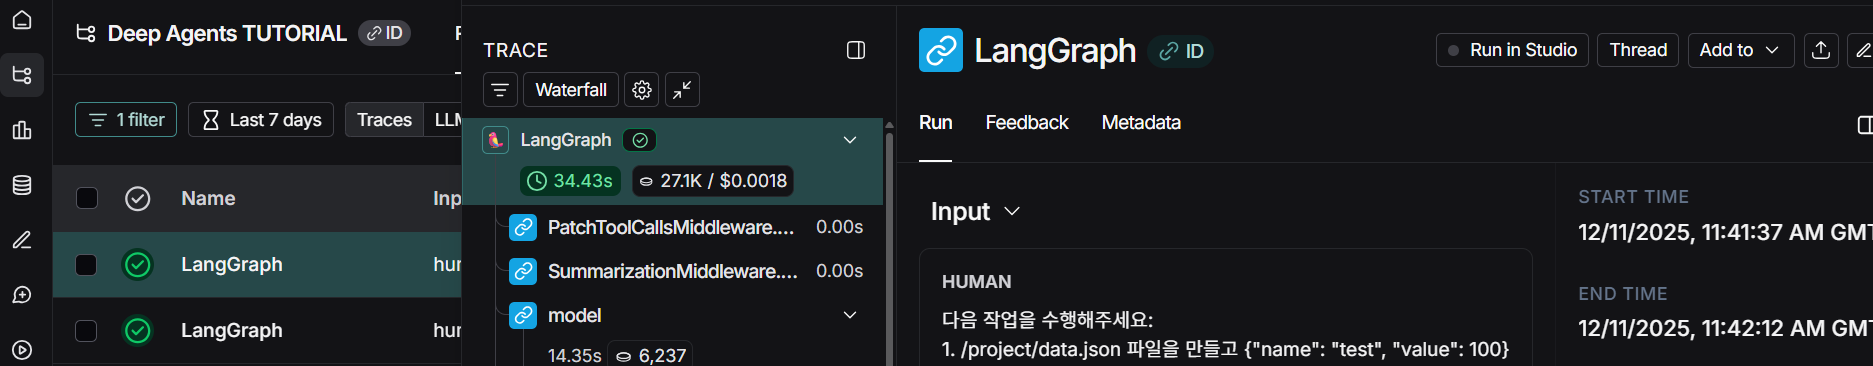

#### 실제로 파일이 생성되었는지 확인

In [21]:
# 실제로 파일이 생성되었는지 확인
import os

print("생성된 파일들:")
for root, dirs, files in os.walk(temp_dir):
    for file in files:
        file_path = os.path.join(root, file)
        print(f"\n파일: {file_path}")
        with open(file_path, 'r', encoding='utf-8') as f:
            print(f"내용: {f.read()}")


생성된 파일들:

파일: C:\dev\github\course_LLM\4. Multi Agents\3. DeepAgents\temp\project\data.json
내용: {"name": "test", "value": 100}

파일: C:\dev\github\course_LLM\4. Multi Agents\3. DeepAgents\temp\project\readme.md
내용: 프로젝트 설명


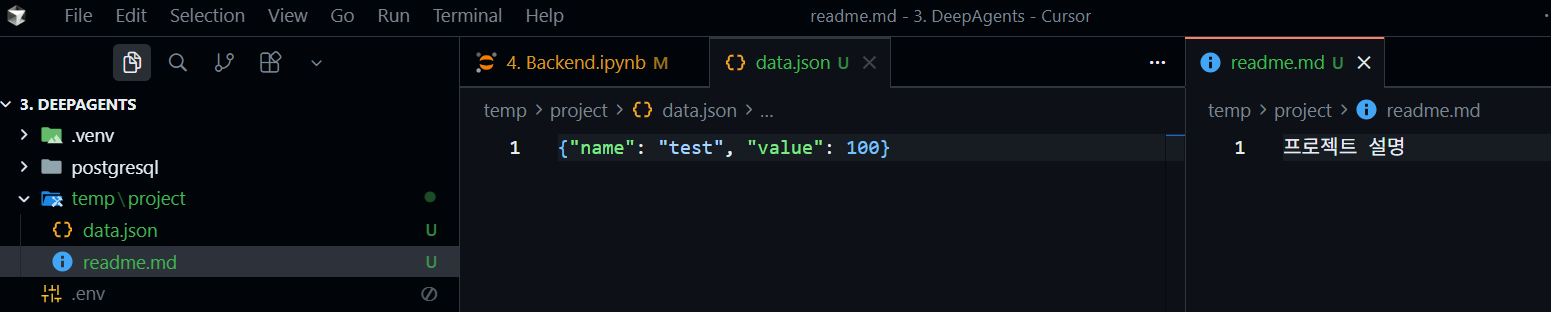

## 6. StoreBackend (Long-term memory)

`StoreBackend`는 LangGraph Store를 활용하여 여러 스레드 간에 데이터를 공유할 수 있습니다.

### 특징
- LangGraph `BaseStore`를 사용하여 파일 저장
- **여러 스레드 간 데이터 공유 가능** (가장 큰 차이점!)
- Redis, Postgres, 클라우드 스토어 등 다양한 백엔드 지원
- 장기 메모리나 여러 세션에서 공유해야 하는 데이터에 적합


### PostgreSQLStore 생성

In [28]:
from langgraph.store.postgres import PostgresStore

# PostgreSQLStore 생성
store = PostgresStore(
    conn=PostgreDB(DB_CONFIG).get_conn()
)
store.setup() # 필요한 테이블 자동 생성

| 테이블명      | 설명                                                                                                   |
| --------- | ---------------------------------------------------------------------------------------------------- |
| **store** | LangGraph의 key-value 데이터 저장을 위한 메인 스토리지 테이블. 에이전트 상태, 메타데이터, 일반 저장 데이터 등을 JSON/BYTE 형태로 저장하는 핵심 테이블. |
| **store_migrations** | PostgresStore 스키마 버전을 관리하는 마이그레이션 기록 테이블. `store.setup()` 실행 시 버전을 확인하여 필요한 스키마 업데이트를 관리. |


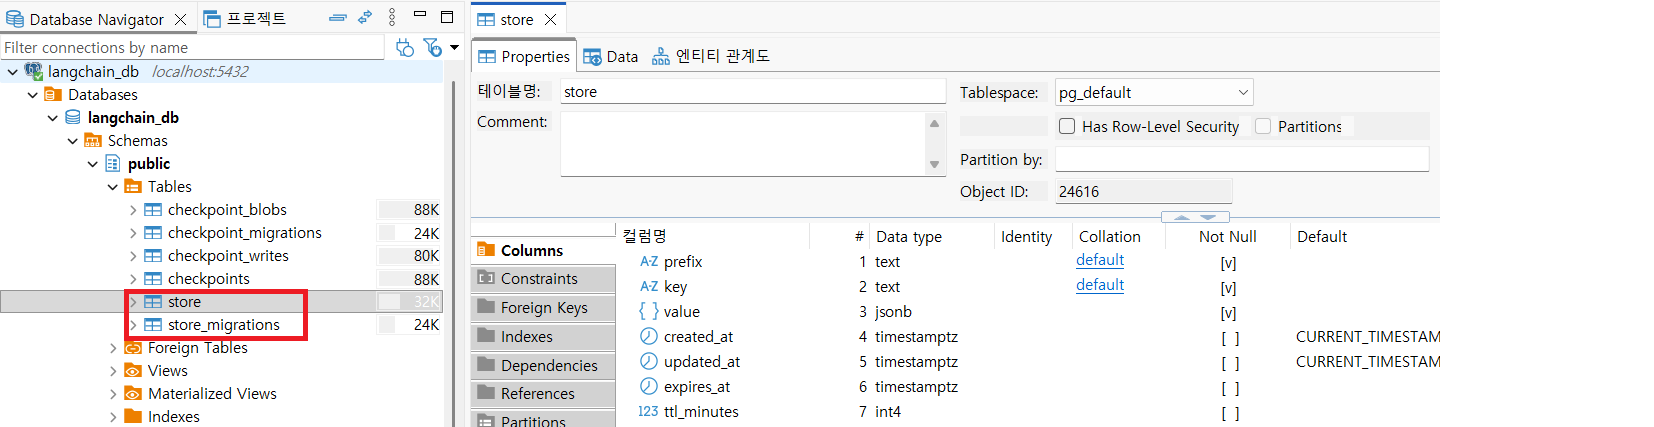

#### Store vs Checkpointer

| 구분 | Store | Checkpointer |
|------|-------------------|---------------------------|
| **주요 용도** | 특정 정보 저장 | 대화 내용 저장 |
| **저장 대상** | 사용자 프로필, 설정, 선호도 등 | 메시지 기록, 대화 흐름, 노드 상태 |
| **저장 방식** | 직접 저장/조회 (수동) | LangGraph가 자동 저장 |
| **데이터 예시** | 이름, 나이, 관심사, 좋아하는 색 | "안녕" → "반가워요" → "도와줘" |
| **테이블 이름** | `store` | `checkpoints`, `writes` |
| **데이터 수명** | 삭제 전까지 영구 보관 | 세션/스레드 단위로 관리 |
| **질문 예시** | "내 이름이 뭐야?" | "아까 뭐라고 했지?" |
| **코드 사용** | `store.put()`, `store.get()` | `config={"thread_id": "..."}` |
| **비유** | 메모장 📝 (필요한 것만 기록) | 녹화기 📹 (전체 대화 녹화) |
| **필수 여부** | 선택 (필요시 사용) | 대화 이어가기에 필수 |

In [29]:
from deepagents.backends import StoreBackend

# StoreBackend 사용
agent_store = create_deep_agent(
    model=llm,
    # backend: DeepAgent가 내부적으로 사용할 Runtime Backend를 지정.
    # StoreBackend는 Runtime(rt)을 받아서, rt.store 를 통해 데이터 저장/조회 기능을 제공.
    backend=(lambda rt: StoreBackend(rt)),
    # store: 에이전트의 메모리/상태를 저장하는 부분.
    store=store
)


### StoreBackend 테스트 - 스레드 1에서 파일 생성


In [30]:
config_thread1 = {"configurable": {"thread_id": "thread-1"}}

response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "/shared/user_preferences.txt 파일을 만들고 '사용자 선호 언어: 한국어'라고 저장해줘."
            }
        ]
    },
    config=config_thread1
)

print(response["messages"][-1].content)


완료했습니다. 파일 경로: /shared/user_preferences.txt
내용: 사용자 선호 언어: 한국어

필요하시면 파일 내용을 다시 확인해 드리거나, 다른 선호 항목도 추가로 저장해 드리겠습니다. 원하는 항목이 있나요?


#### Store에 저장된 데이터 확인 

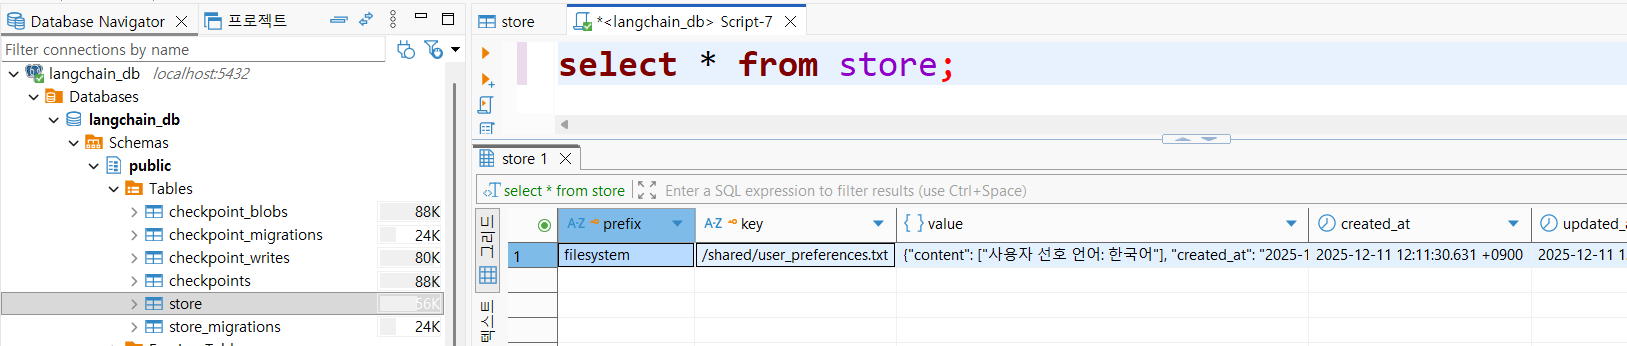

### Checkpointer 테스트 

Checkpointer를 적용하지 않아서 이전 대화내용을 답변하지 못합니다.

In [36]:
response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "이전에 생성했던 파일 내용을 읽어줘."
            }
        ]
    },
    config=config_thread1 # 동일한 thread_id 사용!!
)

print(response["messages"][-1].content)

좋아요. 어떤 파일의 내용을 읽어드릴까요? 파일 경로를 알려주시면 바로 읽겠습니다.

가능한 대안도 몇 가지 제안드립니다.
- 경로를 모르면, 현재 워크스페이스에서 최근에 생성되었거나 수정된 파일을 찾아 읽어드릴 수 있습니다. 진행할까요?
- 특정 키워드를 포함하는 파일을 찾아 읽는 방식도 가능합니다. 원하시면 키워드를 말씀해 주세요.

참고로 읽기는 기본적으로 처음 500줄을 읽으며, 필요하면 offset/limit를 조정해 더 읽을 수 있습니다.

원하시는 방식과 파일 경로를 알려주시면 바로 진행하겠습니다.


### Store 테스트 

thread_id가 다르더라도 store의 데이터를 조회해서 답변을 할 수 있습니다.


In [31]:
config_thread2 = {"configurable": {"thread_id": "thread-2"}}  # 다른 스레드!

response = agent_store.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "/shared/user_preferences.txt 파일을 읽어줘."
            }
        ]
    },
    config=config_thread2
)

print(response["messages"][-1].content)
print("\n다른 스레드(thread-2)에서도 thread-1이 만든 파일을 읽을 수 있습니다!")


다 읽었습니다. /shared/user_preferences.txt의 내용은 다음과 같습니다:

사용자 선호 언어: 한국어

필요하시면 이 정보를 바탕으로 대화를 한국어로 계속 진행하겠습니다. 혹시 선호 언어를 바꾸고 싶으신가요? 파일을 업데이트해 드릴 수도 있습니다.

다른 스레드(thread-2)에서도 thread-1이 만든 파일을 읽을 수 있습니다!


#### [Langsmith](https://smith.langchain.com/)

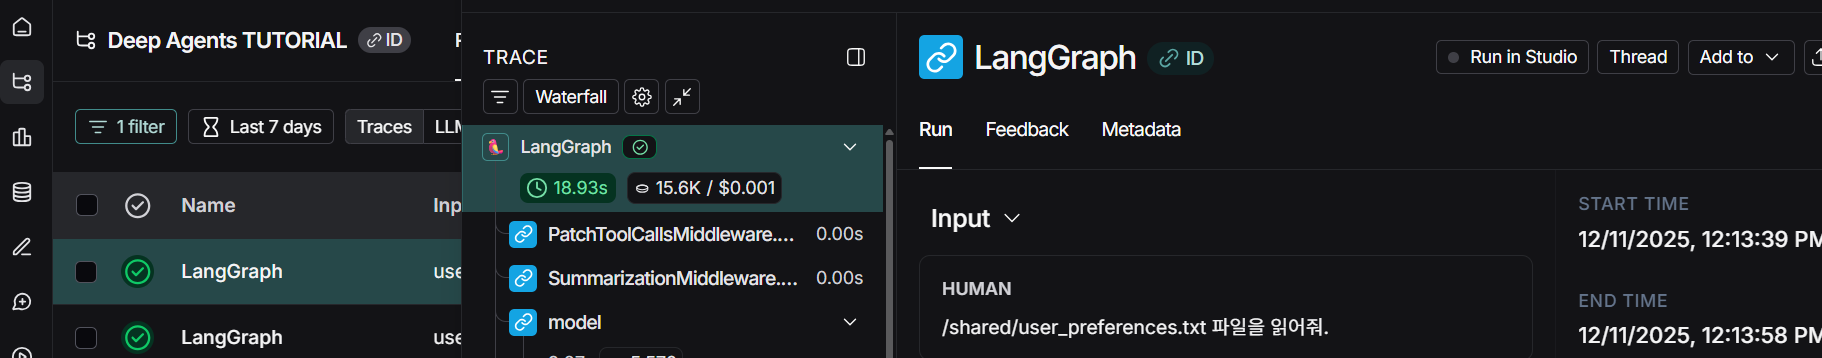

---

## 참고 자료

- [LangChain Deep Agents - Backends 공식 문서](https://docs.langchain.com/oss/python/deepagents/backends)
- [LangGraph Store 문서](https://langchain-ai.github.io/langgraph/concepts/persistence/)
- [BackendProtocol 프로토콜 참조](https://docs.langchain.com/oss/python/deepagents/backends#protocol-reference)
